# Reddit Text Data Cleaning

## Overview

- The data was collected from Arctic Shift's website using the downloader tool that allows you to download historical subbreddit data from reddit
- I collected posts and comments from these subreddits:
    - r/Natalism
    - r/Childfree
    - r/Parenting
    - r/Economic

## Takeaways
| Subreddit | Raw Posts | Clean Posts | Raw Comments | Clean Comments |
|-----------|-----------|-------------|--------------|----------------|
| r/Natalism | 7,262 | 2,293 | 304,630 | 27,557 |
| r/Childfree | 390,140 | 35,594 | 9,859,049 | 619,205 |
| r/Parenting | 522,245 | 2,815 | 10,728,131 | 71,391 |
| r/Economics | 201,419 | 177 | 5,520,422 | 2,630 |

## Libraries

In [1]:
import json
from datetime import datetime, timezone
from collections import Counter
import matplotlib.pyplot as plt

## r/Natalism

### r/Natalism Posts

#### Inspecting the data

In [2]:
natalism_posts = []

# Loading the posts
with open('reddit data/r_Natalism_posts.jsonl', 'r', encoding = 'utf-8') as f:
    for line in f:
        natalism_posts.append(json.loads(line))
print(f"Total r/Natalism posts: {len(natalism_posts)}.")

# Checking posts with empty selftext (e.g. pictures)
empty_selftext = sum(1 for p in natalism_posts if not p.get('selftext', '').strip())
print(f"There are {empty_selftext} r/Natalism posts with empty texts.")

# Pre-filtering year distribution
years_raw = [datetime.fromtimestamp(p['created_utc'], tz = timezone.utc).year for p in natalism_posts]

Total r/Natalism posts: 7262.
There are 3914 r/Natalism posts with empty texts.


#### Filtering the posts

In [4]:
# Defining the keywords for the scraper
KEYWORDS_LOWER = [
    "birth rate", "birth rates", "declining birth rate", "declining birth rates",
    "fertility", "fertility rate", "fertility decline", "declining fertility",
    "fertility crisis", "low fertility", "having kids", "having children",
    "fewer kids", "fewer children", "starting a family", "family formation",
    "natality", "population decline", "falling birth rate", "falling birth rates",
    "depopulation", "demographic decline",
]

def contains_keyword(title, selftext):
    text = (title + ' ' + selftext).lower()
    return any(kw in text for kw in KEYWORDS_LOWER)

# Filtering and selecting columns
seen_ids = set()
natalism_posts_cleaned = []

for p in natalism_posts:
    title = p.get('title', '') or ''
    selftext = p.get('selftext', '') or ''
    # Skip if post was deleted
    if selftext in ('[deleted]', '[removed]'):
        continue
    # Skip if post has no title
    if not title.strip():
        continue
    # Skip if there's no keyword match
    if not contains_keyword(title, selftext):
        continue
    # Skip duplicate posts
    if p['id'] in seen_ids:
        continue
    seen_ids.add(p['id'])
    natalism_posts_cleaned.append({
        'subreddit': p['subreddit'],
        'id': p['id'],
        'title': title,
        'selftext': selftext,
        'created_utc': p['created_utc'],
        'url': p.get('url', ''),
        'score': p.get('score'),
        'num_comments': p.get('num_comments'),
    })
print(f"Total r/Natalism posts after filtering: {len(natalism_posts_cleaned)}")

Total r/Natalism posts after filtering: 2293


#### Plotting the distribution of posts related to birth rates

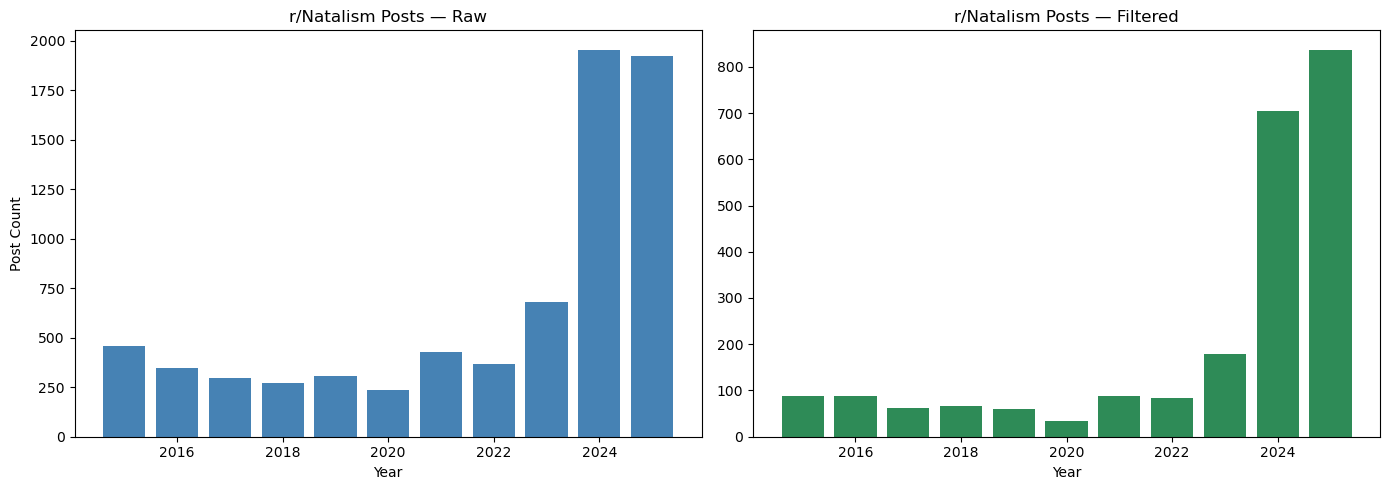

In [5]:
# Plotting Pre vs Post distribution
years_clean = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in natalism_posts_cleaned]
years_raw_counts   = Counter(years_raw)
years_clean_counts = Counter(years_clean)
all_years = sorted(set(years_raw_counts) | set(years_clean_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].bar(all_years, [years_raw_counts.get(y, 0) for y in all_years], color='steelblue')
axes[0].set_title('r/Natalism Posts — Raw')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Post Count')

axes[1].bar(all_years, [years_clean_counts.get(y, 0) for y in all_years], color='seagreen')
axes[1].set_title('r/Natalism Posts — Filtered')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

#### Exporting the cleaned JSONL

### r/Natalism Comments

#### Inspecting the comments

In [6]:
# Loading raw comments
natalism_comments = []
with open('reddit data/r_Natalism_comments.jsonl', 'r', encoding = 'utf-8') as f:
    for line in f:
        natalism_comments.append(json.loads(line))

# Inspecting the dataset
print(f"Total r/Natalism comments: {len(natalism_comments)}")
empty_body = sum(1 for c in natalism_comments if not c.get('body', '').strip())
print(f"Total r/Natalism comments with empty body: {empty_body}")

Total r/Natalism comments: 304630
Total r/Natalism comments with empty body: 0


#### Filtering the comments

In [7]:
# Getting kept post ids
kept_ids = {p['id'] for p in natalism_posts_cleaned}

# Filtering and selecting relevant variables
seen_comment_ids = set()
natalism_comments_cleaned = []

for c in natalism_comments:
    body = c.get('body', '') or ''
    if not c.get('parent_id', '').startswith('t3_'):
        continue
    if body in ('[deleted]', '[removed]'):
        continue
    if not body.strip():
        continue
    post_id = c.get('link_id', '').replace('t3_', '')
    if post_id not in kept_ids:
        continue
    if c['id'] in seen_comment_ids:
        continue
    seen_comment_ids.add(c['id'])
    natalism_comments_cleaned.append({
        'subreddit': c['subreddit'],
        'id': c['id'],
        'body': body,
        'created_utc': c['created_utc'],
        'score': c.get('score'),
        'parent_id': c.get('parent_id'),
        'link_id': c.get('link_id'),
    })
print(f"Total amount of r/Natalism comments after filtering: {len(natalism_comments_cleaned)}")

Total amount of r/Natalism comments after filtering: 27557


#### Exporting the cleaned comments

## r/Childfree

### r/Childfree Posts

#### Inspecting the data

In [8]:
childfree_posts = []

# Loading the posts
with open('reddit data/r_Childfree_posts.jsonl', 'r', encoding = 'utf-8') as f:
    for line in f:
        childfree_posts.append(json.loads(line))
print(f"Total r/Childfree posts: {len(childfree_posts)}.")

# Checking posts with empty selftext (e.g. pictures)
empty_selftext = sum(1 for p in childfree_posts if not p.get('selftext', '').strip())
print(f"There are {empty_selftext} r/Childfree posts with empty texts.")

# Pre-filtering year distribution
years_raw_cf = [datetime.fromtimestamp(p['created_utc'], tz = timezone.utc).year for p in childfree_posts]

Total r/Childfree posts: 390140.
There are 54069 r/Childfree posts with empty texts.


#### Filtering the posts

In [9]:
# Filtering and selecting relevant variables
seen_ids_cf = set()
childfree_posts_clean = []

for p in childfree_posts:
    title = p.get('title', '') or ''
    selftext = p.get('selftext', '') or ''
    if selftext in ('[deleted]', '[removed]'):
        continue
    if not title.strip():
        continue
    if len((title + selftext).strip()) < 50:
        continue
    if not contains_keyword(title, selftext):
        continue
    if p['id'] in seen_ids_cf:
        continue
    seen_ids_cf.add(p['id'])
    childfree_posts_clean.append({
        'subreddit': p['subreddit'],
        'id': p['id'],
        'title': title,
        'selftext': selftext,
        'created_utc': p['created_utc'],
        'url': p.get('url', ''),
        'score': p.get('score'),
        'num_comments': p.get('num_comments'),
    })
print(f"Total r/Childfree posts after filtering: {len(childfree_posts_clean)}")

Total r/Childfree posts after filtering: 35594


#### Plotting the distribution of posts Pre vs Post processing

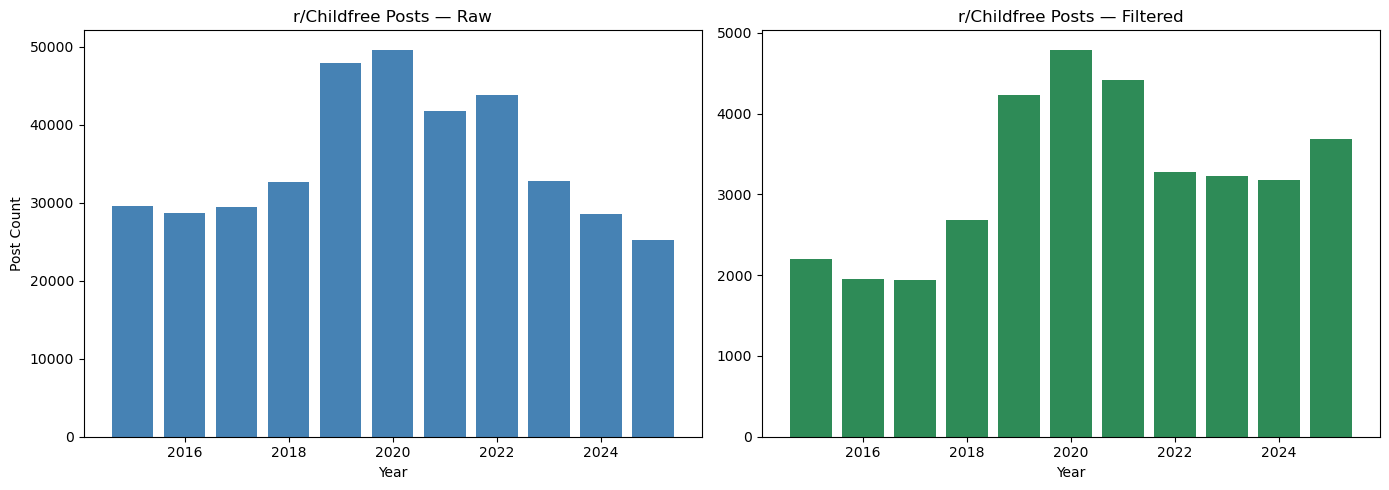

In [10]:
# Plot pre vs post distribution
years_clean_cf = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in childfree_posts_clean]
years_raw_counts_cf   = Counter(years_raw_cf)
years_clean_counts_cf = Counter(years_clean_cf)
all_years_cf = sorted(set(years_raw_counts_cf) | set(years_clean_counts_cf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(all_years_cf, [years_raw_counts_cf.get(y, 0) for y in all_years_cf], color='steelblue')
axes[0].set_title('r/Childfree Posts — Raw')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Post Count')

axes[1].bar(all_years_cf, [years_clean_counts_cf.get(y, 0) for y in all_years_cf], color='seagreen')
axes[1].set_title('r/Childfree Posts — Filtered')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

#### Exporting the cleaned data

### r/Childfree Comments

#### Inspecting the comments

#### Filtering the comments

In [ ]:
# Filtering and selecting relevant variables
seen_comment_ids_cf = set()
childfree_comments_clean = []

for c in childfree_comments:
    body = c.get('body', '') or ''
    if not c.get('parent_id', '').startswith('t3_'):
        continue
    if body in ('[deleted]', '[removed]'):
        continue
    if not body.strip():
        continue
    post_id = c.get('link_id', '').replace('t3_', '')
    if post_id not in kept_post_ids_cf:
        continue
    if c['id'] in seen_comment_ids_cf:
        continue
    seen_comment_ids_cf.add(c['id'])
    childfree_comments_clean.append({
        'subreddit': c['subreddit'],
        'id': c['id'],
        'body': body,
        'created_utc': c['created_utc'],
        'score': c.get('score'),
        'parent_id': c.get('parent_id'),
        'link_id': c.get('link_id'),
    })
print(f"Total r/Childfree comments after filtering: {len(childfree_comments_clean)}")

In [24]:
# Disregard if cell above was ran
# Counting the amounts of comments in the cleaned r/Childfree JSONL file

with open('reddit data/cleaned data/r_Childfree_comments_clean.jsonl', 'r', encoding='utf-8') as f:
    print(sum(1 for line in f))

619205


#### Exporting the cleaned comments

## r/Parenting

### r/Parenting Posts

#### Inspecting the data

In [11]:
# Loading raw posts
parenting_posts = []
with open('reddit data/r_Parenting_posts.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        parenting_posts.append(json.loads(line))

# Inspecting them
print(f"Total r/Parenting posts: {len(parenting_posts)}")
empty_selftext = sum(1 for p in parenting_posts if not p.get('selftext', '').strip())
print(f"Total r/Parenting posts with empty selftext: {empty_selftext}")

# Pre-filtering year distribution
years_raw_par = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in parenting_posts]

Total r/Parenting posts: 522245
Total r/Parenting posts with empty selftext: 2135


#### Filtering the posts

In [12]:
# Filtering and selecting relevant variables
seen_ids_par = set()
parenting_posts_clean = []

for p in parenting_posts:
    title    = p.get('title', '') or ''
    selftext = p.get('selftext', '') or ''
    if selftext in ('[deleted]', '[removed]'):
        continue
    if not title.strip():
        continue
    if len((title + selftext).strip()) < 50:
        continue
    if not contains_keyword(title, selftext):
        continue
    if p['id'] in seen_ids_par:
        continue
    seen_ids_par.add(p['id'])
    parenting_posts_clean.append({
        'subreddit': p['subreddit'],
        'id': p['id'],
        'title': title,
        'selftext': selftext,
        'created_utc': p['created_utc'],
        'url': p.get('url', ''),
        'score': p.get('score'),
        'num_comments': p.get('num_comments'),
    })
print(f"Total r/Parenting posts after filtering: {len(parenting_posts_clean)}")

Total r/Parenting posts after filtering: 2815


#### Plotting the distribution of posts Pre vs Post processing

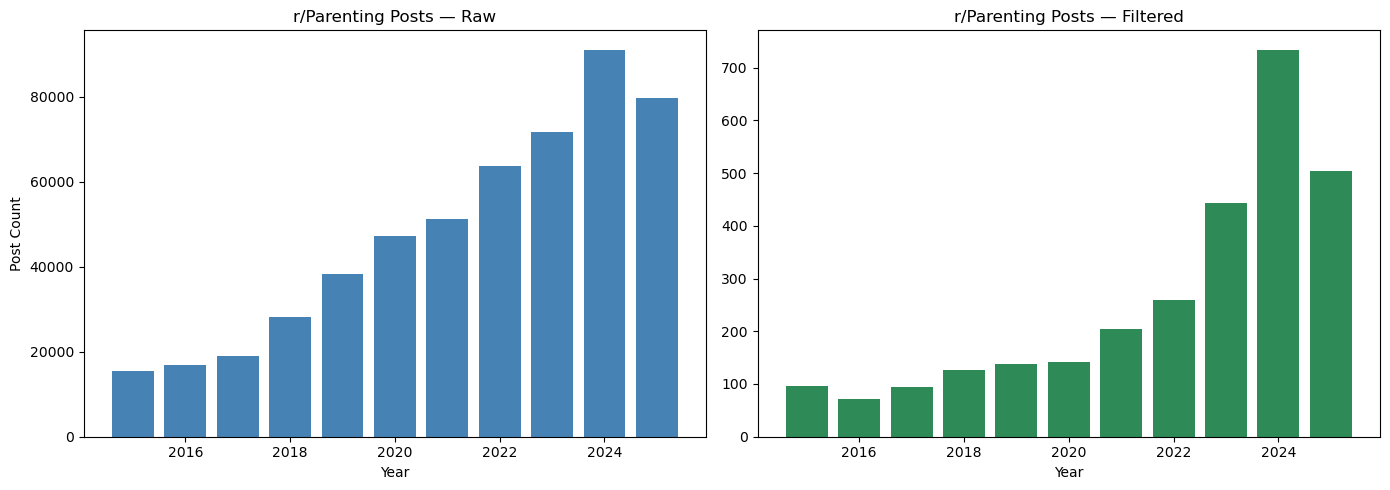

In [13]:
# Plotting pre vs post distribution
years_clean_par = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in parenting_posts_clean]
years_raw_counts_par   = Counter(years_raw_par)
years_clean_counts_par = Counter(years_clean_par)
all_years_par = sorted(set(years_raw_counts_par) | set(years_clean_counts_par))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(all_years_par, [years_raw_counts_par.get(y, 0) for y in all_years_par], color='steelblue')
axes[0].set_title('r/Parenting Posts — Raw')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Post Count')

axes[1].bar(all_years_par, [years_clean_counts_par.get(y, 0) for y in all_years_par], color='seagreen')
axes[1].set_title('r/Parenting Posts — Filtered')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

#### Exporting the cleaned data

### r/Parenting Comments

#### Inspecting & filtering the comments

In [14]:
kept_post_ids_par = {p['id'] for p in parenting_posts_clean}

total, empty, kept = 0, 0, 0
seen = set()

with open('reddit data/r_Parenting_comments.jsonl', 'r', encoding = 'utf-8') as infile, \
     open('reddit data/r_Parenting_comments_clean.jsonl', 'w', encoding = 'utf-8') as outfile:

    for line in infile:
        c = json.loads(line)
        body = c.get('body', '') or ''
        total += 1
        if not body.strip(): empty += 1

        if not c.get('parent_id', '').startswith('t3_'): continue
        if body in ('[deleted]', '[removed]'): continue
        if not body.strip(): continue
        if c.get('link_id', '').replace('t3_', '') not in kept_post_ids_par: continue
        if c['id'] in seen: continue
        seen.add(c['id'])

        outfile.write(json.dumps({'subreddit': c['subreddit'], 'id': c['id'], 'body': body,
            'created_utc': c['created_utc'], 'score': c.get('score'),
            'parent_id': c.get('parent_id'), 'link_id': c.get('link_id')}) + '\n')
        kept += 1

print(f"Total Comments: {total} | Empty Comments: {empty} | Kept Comments: {kept}")

Total Comments: 10728131 | Empty Comments: 41 | Kept Comments: 71391


## r/Economics

### r/Economics Posts

#### Inspecting the data

In [15]:
# Loading raw posts
economics_posts = []
with open('reddit data/r_Economics_posts.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        economics_posts.append(json.loads(line))

# Inspecting them
print(f"Total r/Economics posts: {len(economics_posts)}")
empty_selftext = sum(1 for p in economics_posts if not p.get('selftext', '').strip())
print(f"Total r/Economics posts with empty selftext: {empty_selftext}")

# Pre-filtering year distribution
years_raw_eco = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in economics_posts]

Total r/Economics posts: 201419
Total r/Economics posts with empty selftext: 176114


#### Filtering the posts

In [16]:
# Filtering and selecting relevant variables
seen_ids_eco = set()
economics_posts_clean = []

for p in economics_posts:
    title    = p.get('title', '') or ''
    selftext = p.get('selftext', '') or ''
    if selftext in ('[deleted]', '[removed]'):
        continue
    if not title.strip():
        continue
    if len((title + selftext).strip()) < 50:
        continue
    if not contains_keyword(title, selftext):
        continue
    if p['id'] in seen_ids_eco:
        continue
    seen_ids_eco.add(p['id'])
    economics_posts_clean.append({
        'subreddit': p['subreddit'],
        'id': p['id'],
        'title': title,
        'selftext': selftext,
        'created_utc': p['created_utc'],
        'url': p.get('url', ''),
        'score': p.get('score'),
        'num_comments': p.get('num_comments'),
    })
print(f"Total r/Economics posts after filtering: {len(economics_posts_clean)}")

Total r/Economics posts after filtering: 177


#### Plotting the distribution of posts Pre vs Post processing

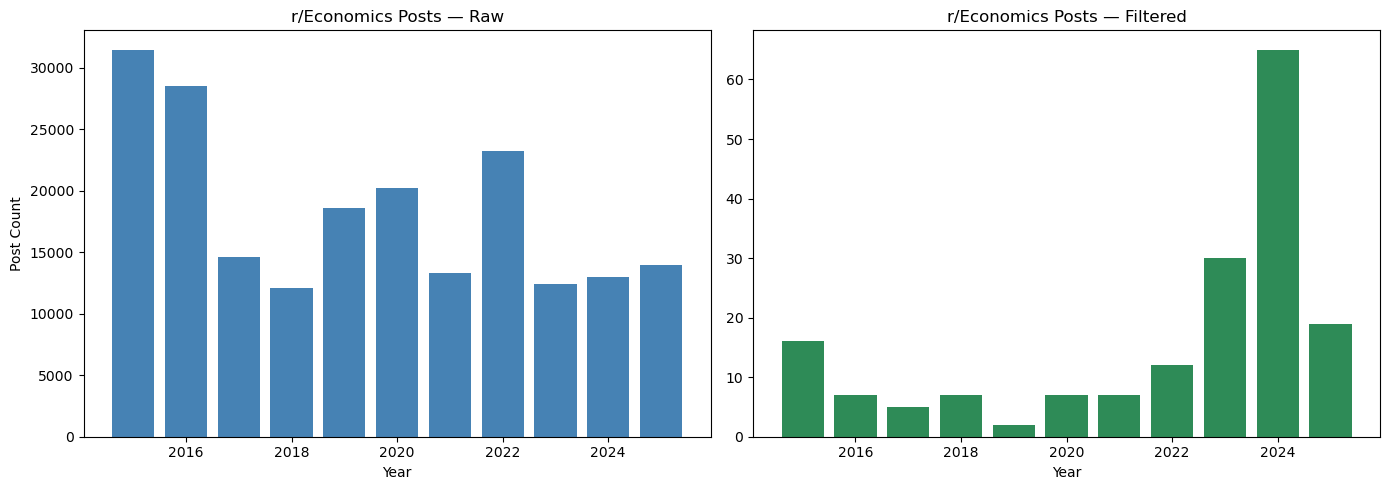

In [17]:
# Plotting pre vs post distribution
years_clean_eco = [datetime.fromtimestamp(p['created_utc'], tz=timezone.utc).year for p in economics_posts_clean]
years_raw_counts_eco   = Counter(years_raw_eco)
years_clean_counts_eco = Counter(years_clean_eco)
all_years_eco = sorted(set(years_raw_counts_eco) | set(years_clean_counts_eco))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(all_years_eco, [years_raw_counts_eco.get(y, 0) for y in all_years_eco], color='steelblue')
axes[0].set_title('r/Economics Posts — Raw')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Post Count')

axes[1].bar(all_years_eco, [years_clean_counts_eco.get(y, 0) for y in all_years_eco], color='seagreen')
axes[1].set_title('r/Economics Posts — Filtered')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

#### Exporting the cleaned data

In [18]:
with open('reddit data/r_Economics_posts_clean.jsonl', 'w', encoding='utf-8') as f:
    for post in economics_posts_clean:
        f.write(json.dumps(post) + '\n')

### r/Economics Commments

#### Inspecting the comments

In [19]:
# Loading raw comments
economics_comments = []
with open('reddit data/r_Economics_comments.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        economics_comments.append(json.loads(line))

# Inspecting them
print(f"Total r/Economics comments: {len(economics_comments)}")
empty_body = sum(1 for c in economics_comments if not c.get('body', '').strip())
print(f"Total r/Economics comments with empty body: {empty_body}")

# Get kept post IDs
kept_post_ids_eco = {p['id'] for p in economics_posts_clean}

Total r/Economics comments: 5520422
Total r/Economics comments with empty body: 23


#### Filtering the comments

In [20]:
# Filtering and selecting relevant variables
seen_comment_ids_eco = set()
economics_comments_clean = []

for c in economics_comments:
    body = c.get('body', '') or ''
    if not c.get('parent_id', '').startswith('t3_'):
        continue
    if body in ('[deleted]', '[removed]'):
        continue
    if not body.strip():
        continue
    post_id = c.get('link_id', '').replace('t3_', '')
    if post_id not in kept_post_ids_eco:
        continue
    if c['id'] in seen_comment_ids_eco:
        continue
    seen_comment_ids_eco.add(c['id'])
    economics_comments_clean.append({
        'subreddit': c['subreddit'],
        'id': c['id'],
        'body': body,
        'created_utc': c['created_utc'],
        'score': c.get('score'),
        'parent_id': c.get('parent_id'),
        'link_id': c.get('link_id'),
    })
print(f"Total r/Economics comments after filtering: {len(economics_comments_clean)}")

Total r/Economics comments after filtering: 2630


#### Exporting the cleaned comments

In [21]:
with open('reddit data/r_Economics_comments_clean.jsonl', 'w', encoding='utf-8') as f:
    for comment in economics_comments_clean:
        f.write(json.dumps(comment) + '\n')